<a href="https://colab.research.google.com/github/meghs1716/Machine-Learning-projects/blob/main/obesity_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍨 OBESITY PREDICTION USING DESICION TREE CLASSIFIER

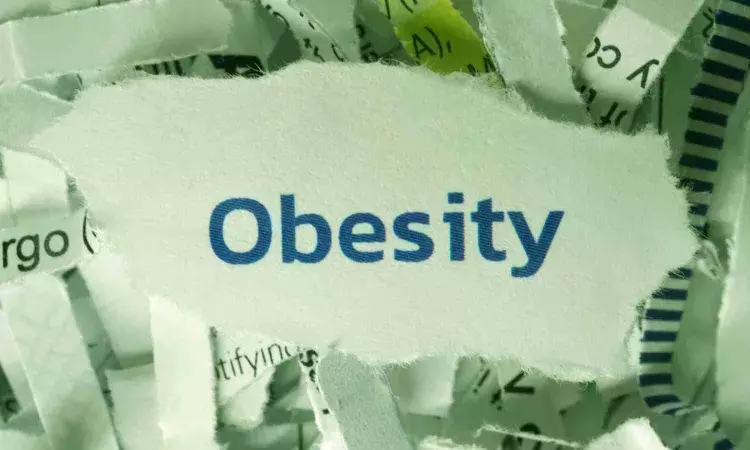

Obesity is a chronic, multifactorial disease defined by abnormal or excessive fat accumulation that impairs health. Driven by genetics, environment, and metabolism, it is a primary risk factor for type 2 diabetes and heart disease.

*In this project, we aim to predict obesity level in individuals having various lifestyles,habits and hereditary factors by applying ML algorithms*

importing libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [7]:
data=pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv")


In [8]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [10]:
num_data=data.select_dtypes(include=['int','float64'])
num_data
# 8 columns are of numeric type


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21.000000,1.620000,64.000000,2.0,3.0,2.000000,0.000000,1.000000
1,21.000000,1.520000,56.000000,3.0,3.0,3.000000,3.000000,0.000000
2,23.000000,1.800000,77.000000,2.0,3.0,2.000000,2.000000,1.000000
3,27.000000,1.800000,87.000000,3.0,3.0,2.000000,2.000000,0.000000
4,22.000000,1.780000,89.800000,2.0,1.0,2.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2106,20.976842,1.710730,131.408528,3.0,3.0,1.728139,1.676269,0.906247
2107,21.982942,1.748584,133.742943,3.0,3.0,2.005130,1.341390,0.599270
2108,22.524036,1.752206,133.689352,3.0,3.0,2.054193,1.414209,0.646288
2109,24.361936,1.739450,133.346641,3.0,3.0,2.852339,1.139107,0.586035


In [11]:
data.select_dtypes(include='object')
# 8 column are qualitative type- excluding target

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,Normal_Weight
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,Normal_Weight
3,Male,no,no,Sometimes,no,no,Frequently,Walking,Overweight_Level_I
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...
2106,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III


In [12]:
data.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [13]:
data.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


 # feature analysis and engineering

In [14]:
data

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


**The columns represent the following personal and lifestyle factors:**


Demographics & Body MetricsGender: Biological sex (Male or Female).

Age: Individual's age in years.

Height: Height measured in meters.Weight: Weight measured in kilograms.

family_history_with_overweight: Indicates if a family member suffers or has suffered from being overweight (yes/no).


MTRANS: Main mode of transportation (e.g., Public_Transportation, Automobile, Walking, Motorbike, Bike).


FAVC: Frequent consumption of high-caloric food (yes/no).

FCVC: Frequency of consuming vegetables (1 = never, 2 = sometimes, 3 = always).


NCP: Number of main meals consumed daily.


CAEC: Consumption of food between meals (no, Sometimes, Frequently, Always).

CH2O: Daily water consumption.

CALC: Frequency of alcohol consumption (no, Sometimes, Frequently, Always).

FAF: Frequency of physical activity.


TUE: Time spent using technological devices (e.g., cell phones, televisions, computers).


SCC: Calories consumption monitoring (yes/no).



SMOKE: Smoking status (yes/no).

Target Variable : NObeyes-=: The classification of the individual's obesity level, which includes categories such as Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II, and Obesity Type III.


In [15]:
data['fam_hist_ow']=data['family_history_with_overweight']
data['freq_cons_alcholo']=data['FAVC']
data['freq_cons_veggies']=data['FCVC']
data['num_meals_per_week']=data['NCP']
data['cons_food_btwn_meals']=data['CAEC']
data['smoke']=data['SMOKE']
data['cons_of_water_daily']=data['CH2O']
data['monitoring_cal']=data['SCC']
data['freq_physical_act']=data['FAF']
data['screen_time']=data['TUE']
data['cons_of_alcohol']=data['CALC']
data['mode_of_transport']=data['MTRANS']
data['target']=data['NObeyesdad']
data.drop(columns=['family_history_with_overweight','FAVC','FCVC','NCP','CAEC','SMOKE','CH2O','SCC','FAF','TUE','CALC','MTRANS','NObeyesdad'],inplace=True)

In [16]:
data.drop('NObeyesdad', axis=1,inplace=True)

KeyError: "['NObeyesdad'] not found in axis"

In [17]:
data

,Gender,Age,Height,Weight,fam_hist_ow,freq_cons_alcholo,freq_cons_veggies,num_meals_per_week,cons_food_btwn_meals,smoke,cons_of_water_daily,monitoring_cal,freq_physical_act,screen_time,cons_of_alcohol,mode_of_transport,target
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


# Exploratory Data Analysis

<Axes: xlabel='Age', ylabel='target'>

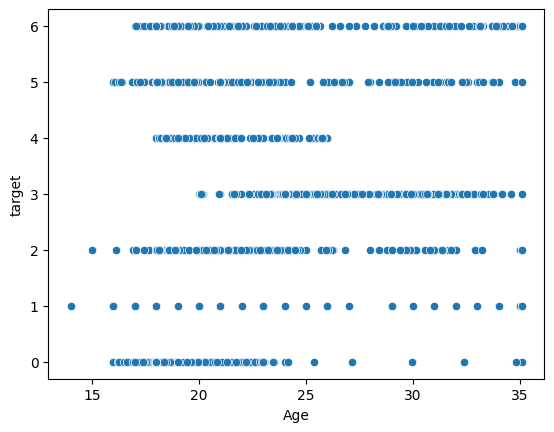

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=data,x="Age",y="target")

### Distributions of Key Numerical Features

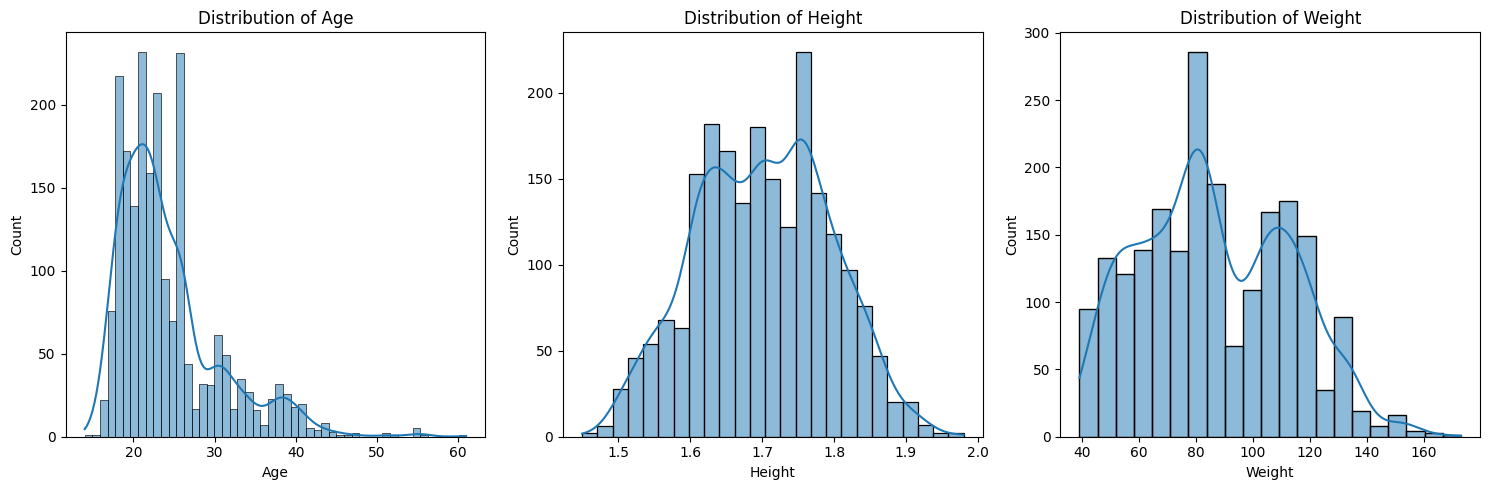

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(data['Height'], kde=True)
plt.title('Distribution of Height')

plt.subplot(1, 3, 3)
sns.histplot(data['Weight'], kde=True)
plt.title('Distribution of Weight')

plt.tight_layout()
plt.show()

### Counts of Key Categorical/Binary Features

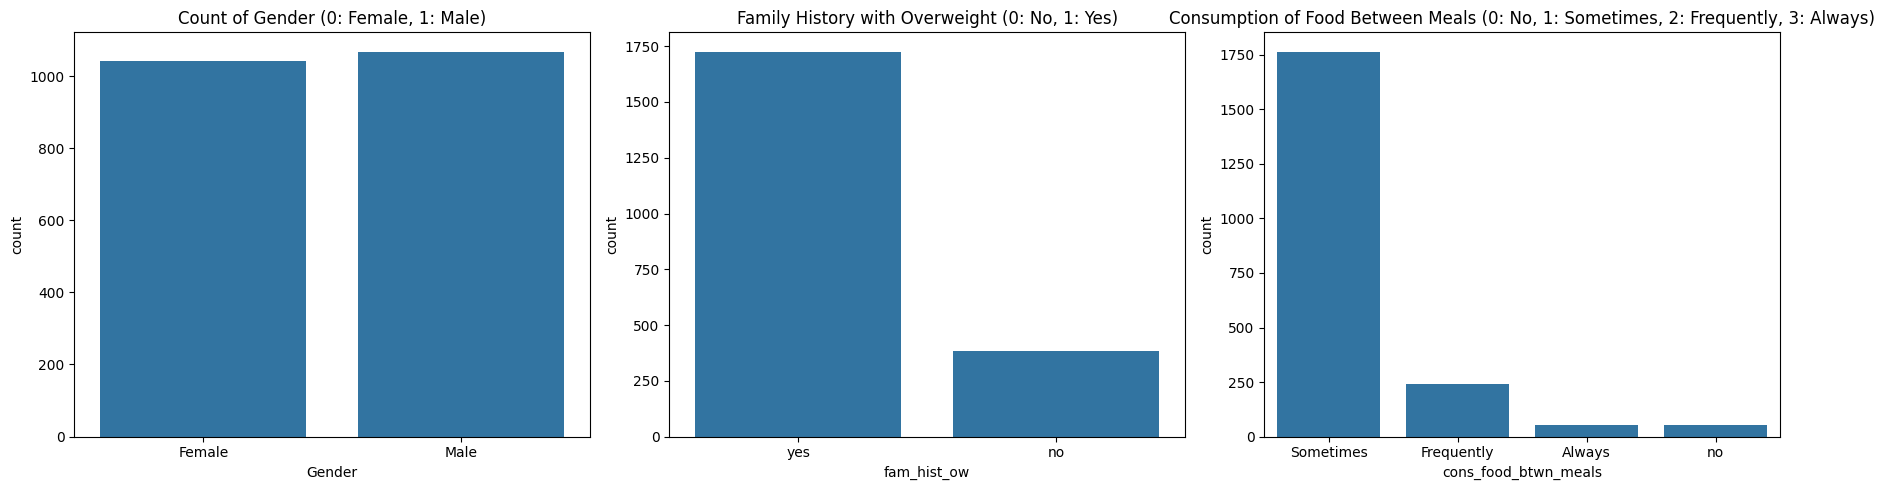

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='Gender', data=data)
plt.title('Count of Gender (0: Female, 1: Male)')

plt.subplot(1, 3, 2)
sns.countplot(x='fam_hist_ow', data=data)
plt.title('Family History with Overweight (0: No, 1: Yes)')

plt.subplot(1, 3, 3)
sns.countplot(x='cons_food_btwn_meals', data=data)
plt.title('Consumption of Food Between Meals (0: No, 1: Sometimes, 2: Frequently, 3: Always)')

plt.tight_layout()
plt.show()

### Relationship between Age and Target Variable (Obesity Level)

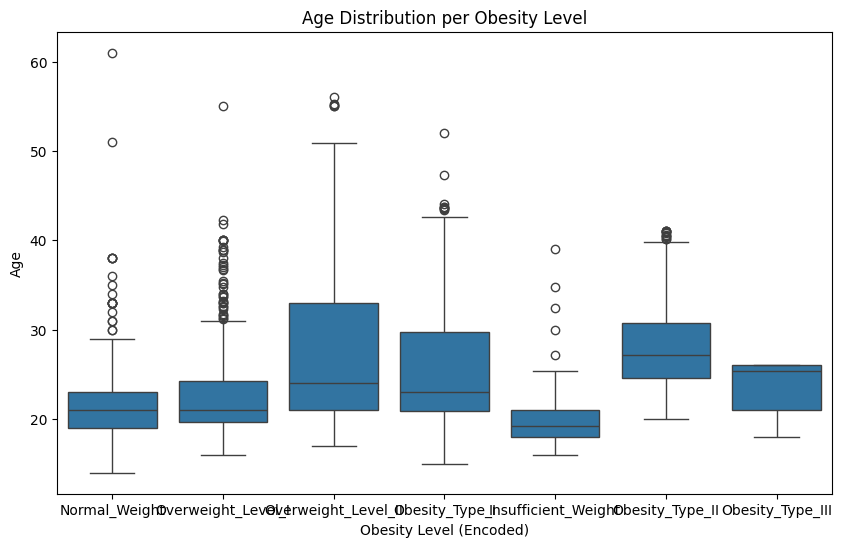

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='Age', data=data)
plt.title('Age Distribution per Obesity Level')
plt.xlabel('Obesity Level (Encoded)')
plt.ylabel('Age')
plt.show()

<Figure size 5000x1000 with 0 Axes>

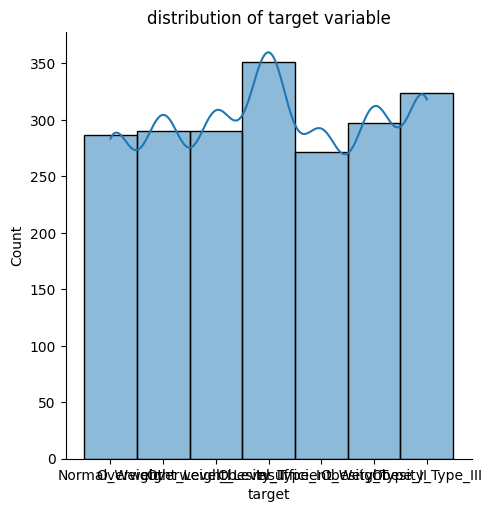

In [ ]:
plt.figure(figsize=(50,10))
sns.displot(data=data,x='target',kde=True)
plt.title("distribution of target variable")
plt.xlabel("target")
plt.show()

# ENCODING

In [26]:
# Reload the original dataset to ensure a clean state for all transformations
data = pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv")

data['fam_hist_ow'] = data['family_history_with_overweight']
data['freq_cons_alcholo'] = data['FAVC']
data['freq_cons_veggies'] = data['FCVC']
data['num_meals_per_week'] = data['NCP']
data['cons_food_btwn_meals'] = data['CAEC']
data['smoke'] = data['SMOKE']
data['cons_of_water_daily'] = data['CH2O']
data['monitoring_cal'] = data['SCC']
data['freq_physical_act'] = data['FAF']
data['screen_time'] = data['TUE']
data['cons_of_alcohol'] = data['CALC']
data['mode_of_transport'] = data['MTRANS']
data['target'] = data['NObeyesdad']

data.drop(columns=[
    'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE',
    'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'
], inplace=True)



# Gender mapping
gendermap = {'Female': 0, 'Male': 1}
data['Gender'] = data['Gender'].str.strip().str.title().map(gendermap)

# Binary mapping (with string cleaning for robustness)
binmap = {'yes': 1, 'no': 0}
bincols = ['fam_hist_ow', 'freq_cons_alcholo', 'smoke', 'monitoring_cal']
for col in bincols:
    data[col] = data[col].str.strip().str.lower().map(binmap)

# Ordinal mapping

ordmap = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
ordcols = ['cons_food_btwn_meals', 'cons_of_alcohol']
for col in ordcols:
    data[col] = data[col].str.strip().map(ordmap)

# One-Hot Encoding for 'mode_of_transport'
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
mode_of_transport_encoded = ohe.fit_transform(data[['mode_of_transport']])

# Get feature names for the new one-hot encoded columns
mode_of_transport_df = pd.DataFrame(
    mode_of_transport_encoded,
    columns=ohe.get_feature_names_out(['mode_of_transport']),
    index=data.index
)

# Concatenate the new one-hot encoded columns with the original DataFrame
data = pd.concat([data, mode_of_transport_df], axis=1)

data.drop('mode_of_transport', axis=1, inplace=True)


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['target'] = le.fit_transform(data['target'])

out_data = ['Age', 'Height', 'Weight', 'num_meals_per_week']
for col in out_data:

    if pd.api.types.is_numeric_dtype(data[col]):
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        lower_bound = Q1 - 1.5 * (Q3 - Q1)
        upper_bound = Q3 + 1.5 * (Q3 - Q1)
        data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
    else:
        print(f"Warning: Column '{col}' is not numeric and will not be clipped.")

print("\nDataFrame info after all preprocessing and encoding:")
data.info()

print("\nProcessed DataFrame head:")
display(data.head())


DataFrame info after all preprocessing and encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   2111 non-null   int64  
 1   Age                                      2111 non-null   float64
 2   Height                                   2111 non-null   float64
 3   Weight                                   2111 non-null   float64
 4   fam_hist_ow                              2111 non-null   int64  
 5   freq_cons_alcholo                        2111 non-null   int64  
 6   freq_cons_veggies                        2111 non-null   float64
 7   num_meals_per_week                       2111 non-null   float64
 8   cons_food_btwn_meals                     2111 non-null   int64  
 9   smoke                                    2111 non-null   int64  

,Gender,Age,Height,Weight,fam_hist_ow,freq_cons_alcholo,freq_cons_veggies,num_meals_per_week,cons_food_btwn_meals,smoke,...,monitoring_cal,freq_physical_act,screen_time,cons_of_alcohol,target,mode_of_transport_Automobile,mode_of_transport_Bike,mode_of_transport_Motorbike,mode_of_transport_Public_Transportation,mode_of_transport_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.000000,1,0,...,0,0.0,1.0,0,1,0.0,0.0,0.0,1.0,0.0
1,0,21.0,1.52,56.0,1,0,3.0,3.000000,1,1,...,1,3.0,0.0,1,1,0.0,0.0,0.0,1.0,0.0
2,1,23.0,1.80,77.0,1,0,2.0,3.000000,1,0,...,0,2.0,1.0,2,1,0.0,0.0,0.0,1.0,0.0
3,1,27.0,1.80,87.0,0,0,3.0,3.000000,1,0,...,0,2.0,0.0,2,5,0.0,0.0,0.0,0.0,1.0
4,1,22.0,1.78,89.8,0,0,2.0,2.146845,1,0,...,0,0.0,0.0,1,6,0.0,0.0,0.0,1.0,0.0


In [27]:
data.head()

,Gender,Age,Height,Weight,fam_hist_ow,freq_cons_alcholo,freq_cons_veggies,num_meals_per_week,cons_food_btwn_meals,smoke,...,monitoring_cal,freq_physical_act,screen_time,cons_of_alcohol,target,mode_of_transport_Automobile,mode_of_transport_Bike,mode_of_transport_Motorbike,mode_of_transport_Public_Transportation,mode_of_transport_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.000000,1,0,...,0,0.0,1.0,0,1,0.0,0.0,0.0,1.0,0.0
1,0,21.0,1.52,56.0,1,0,3.0,3.000000,1,1,...,1,3.0,0.0,1,1,0.0,0.0,0.0,1.0,0.0
2,1,23.0,1.80,77.0,1,0,2.0,3.000000,1,0,...,0,2.0,1.0,2,1,0.0,0.0,0.0,1.0,0.0
3,1,27.0,1.80,87.0,0,0,3.0,3.000000,1,0,...,0,2.0,0.0,2,5,0.0,0.0,0.0,0.0,1.0
4,1,22.0,1.78,89.8,0,0,2.0,2.146845,1,0,...,0,0.0,0.0,1,6,0.0,0.0,0.0,1.0,0.0


# checking for outliers


<Axes: >

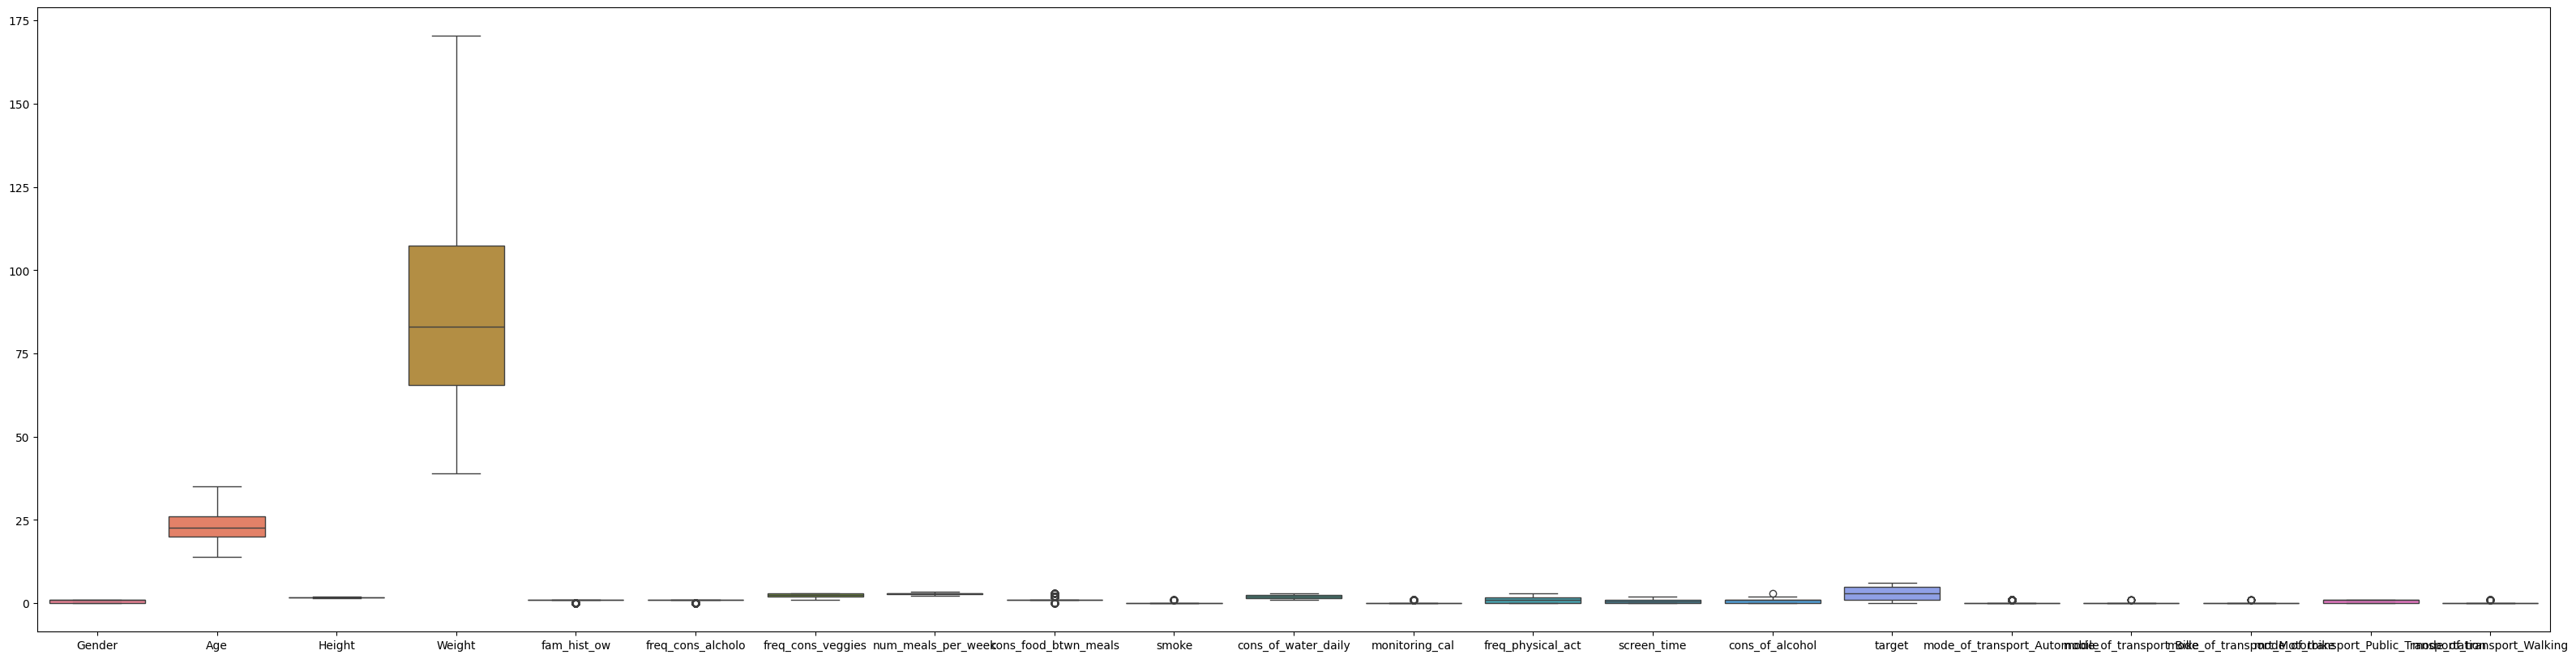

In [28]:
plt.figure(figsize=(40,10))
sns.boxplot(data=data)

In [29]:
num_data = data.select_dtypes(include=['int', 'float64'])

outlier_counts = {}
for column in num_data.columns:
    Q1 = num_data[column].quantile(0.25)
    Q3 = num_data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = num_data[(num_data[column] < lower_bound) | (num_data[column] > upper_bound)]
    outlier_counts[column] = len(outliers)



print("Number of outliers per numerical column:")

for col, count in outlier_counts.items():
    print(f"{col}: {count}")


Number of outliers per numerical column:
Gender: 0
Age: 0
Height: 0
Weight: 0
fam_hist_ow: 385
freq_cons_alcholo: 245
freq_cons_veggies: 0
num_meals_per_week: 0
cons_food_btwn_meals: 346
smoke: 44
cons_of_water_daily: 0
monitoring_cal: 96
freq_physical_act: 0
screen_time: 0
cons_of_alcohol: 1
target: 0
mode_of_transport_Automobile: 457
mode_of_transport_Bike: 7
mode_of_transport_Motorbike: 11
mode_of_transport_Public_Transportation: 0
mode_of_transport_Walking: 56


capping outliers


In [30]:

out_data=['Age','Height','Weight','num_meals_per_week']
for i in out_data:
  data[col]=data[col].clip(lower=data[col].quantile(0.25),upper=data[col].quantile(0.75))

 splitting data into train and test

In [31]:
from sklearn.model_selection import train_test_split,GridSearchCV
x=data.drop('target',axis=1)
y=data['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=44)

In [32]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

# model training

logistic regression

In [33]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train_scaled,y_train)
lr.score(x_test_scaled,y_test)

0.8841607565011821

Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train_scaled,y_train)
dt.score(x_test_scaled,y_test)

0.9479905437352246

SVM

In [58]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train_scaled,y_train)
svm.score(x_test_scaled,y_test)

0.8723404255319149

# Evaluation

In [51]:
from sklearn.metrics import classification_report,confusion_matrix
dt_pred=dt.predict(x_test_scaled)
print("confusion matrix\n",confusion_matrix(y_test,dt_pred))
print("classification report\n\n",classification_report(y_test,dt_pred))


confusion matrix
 [[51  1  0  0  0  0  0]
 [ 6 49  0  0  0  4  0]
 [ 0  0 76  1  0  0  2]
 [ 0  0  3 64  0  0  0]
 [ 0  0  1  0 59  0  0]
 [ 0  1  0  0  0 55  2]
 [ 0  0  1  0  0  0 47]]
classification report

               precision    recall  f1-score   support

           0       0.89      0.98      0.94        52
           1       0.96      0.83      0.89        59
           2       0.94      0.96      0.95        79
           3       0.98      0.96      0.97        67
           4       1.00      0.98      0.99        60
           5       0.93      0.95      0.94        58
           6       0.92      0.98      0.95        48

    accuracy                           0.95       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.95      0.95      0.95       423



In [50]:
lr_pred=lr.predict(x_test_scaled)
print()
print("confusion matrix\n\n",confusion_matrix(y_test,lr_pred))
print("classification report\n\n",classification_report(y_test,lr_pred))



confusion matrix

 [[49  3  0  0  0  0  0]
 [ 7 45  0  0  0  7  0]
 [ 0  0 70  5  1  2  1]
 [ 0  0  3 64  0  0  0]
 [ 0  0  0  1 59  0  0]
 [ 0  2  0  0  0 47  9]
 [ 0  0  2  0  0  6 40]]
classification report

               precision    recall  f1-score   support

           0       0.88      0.94      0.91        52
           1       0.90      0.76      0.83        59
           2       0.93      0.89      0.91        79
           3       0.91      0.96      0.93        67
           4       0.98      0.98      0.98        60
           5       0.76      0.81      0.78        58
           6       0.80      0.83      0.82        48

    accuracy                           0.88       423
   macro avg       0.88      0.88      0.88       423
weighted avg       0.89      0.88      0.88       423



In [60]:
svm_pred=svm.predict(x_test_scaled)

print("confusion matrix\n\n",confusion_matrix(y_test,svm_pred))
print("classification report\n\n",classification_report(y_test,svm_pred))

confusion matrix

 [[48  4  0  0  0  0  0]
 [ 2 45  1  0  0  9  2]
 [ 0  1 71  4  0  1  2]
 [ 0  2  2 63  0  0  0]
 [ 0  1  0  1 58  0  0]
 [ 0  7  3  0  0 45  3]
 [ 0  2  3  0  0  4 39]]
classification report

               precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.73      0.76      0.74        59
           2       0.89      0.90      0.89        79
           3       0.93      0.94      0.93        67
           4       1.00      0.97      0.98        60
           5       0.76      0.78      0.77        58
           6       0.85      0.81      0.83        48

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.87      0.87      0.87       423



### Cross-Validation with Scaling using Pipeline

To ensure proper scaling within each fold of cross-validation and avoid data leakage, we'll create a Pipeline that first scales the data and then applies the model.

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier())
])

lr_pipeline_scores = cross_val_score(lr_pipeline, x, y, cv=6)
dt_pipeline_scores = cross_val_score(dt_pipeline, x, y, cv=6)

print("Logistic Regression Pipeline Cross-Validation Scores:", lr_pipeline_scores)
print(f"LR Accuracy: {lr_pipeline_scores.mean():.4f} ± {lr_pipeline_scores.std():.4f}")


print("\nDecision Tree Pipeline Cross-Validation Scores:", dt_pipeline_scores)
print(f"DT Accuracy: {dt_pipeline_scores.mean():.4f} ± {dt_pipeline_scores.std():.4f}")


Logistic Regression Pipeline Cross-Validation Scores: [0.67329545 0.90340909 0.88352273 0.92613636 0.90625    0.94017094]
LR Accuracy: 0.8721 ± 0.0907

Decision Tree Pipeline Cross-Validation Scores: [0.83238636 0.94602273 0.95738636 0.93465909 0.94318182 0.96296296]
DT Accuracy: 0.9294 ± 0.0444


 *the hyperparameter scores are almost similar to accuracy scores, hence proving the model is not retaining data patterns and is overall a generalized model*